In [2]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [3]:
#Load the dataset
data = load_breast_cancer()

x = data.data
y = data.target

In [4]:
print(x.shape)
print(y.shape)

(569, 30)
(569,)


In [5]:
#Split the dataset for training and testing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [6]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [7]:
#Reshape Data Properly
x_train = x_train.T #Transpose the training data
x_test = x_test.T

y_train = y_train.reshape(1, -1) #Reshape the target variable to be a row vector ex,[[0, 1, 0, ...]]
y_test = y_test.reshape(1, -1)

print("x_trian:",x_train.shape)
print("y_train:",y_train.shape)

x_trian: (30, 455)
y_train: (1, 455)


In [8]:
#Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z)) #(1 / (1 + e^(-z))) where e is the base of the natural logarithm and z is the input to the function.

In [9]:
print(sigmoid(0))

0.5


In [12]:
#Initialize Parameters
def initialize_parameters(n_x, n_h, n_y): #n_x is the number of input features, n_h is the number of neurons in the hidden layer,
                                          #n_y is the number of output classes.
    np.random.seed(42)
    
    W1 = np.random.randn(n_h,n_x)*0.01 #Randomly initialize the weights for the first layer (W1) with small random values. The shape of W1 is (n_h, n_x) because it connects the input layer to the hidden layer.
    b1 = np.zeros((n_h,1)) #Initialize the bias for the first layer (b1) to zeros. The shape of b1 is (n_h, 1) because it is added to the output of the hidden layer.
    
    W2 = np.random.randn(n_y,n_h)*0.01 #Randomly initialize the weights for the second layer (W2) with small random values. The shape of W2 is (n_y, n_h) because it connects the hidden layer to the output layer.
    b2 = np.zeros((n_y,1)) #Initialize the bias for the second layer (b2) to zeros. The shape of b2 is (n_y, 1) because it is added to the output of the output layer.
    
    return  W1,b1,W2,b2

In [13]:
n_x = x_train.shape[0] #Number of input features is the number of rows in the training data (after transposing)
n_h = 5 
n_y = 1 

W1, b1, W2, b2 = initialize_parameters(n_x,n_h,n_y) 

In [15]:
print(W1.shape)
print(b1.shape)
print(W2.shape)
print(b2.shape)

(5, 30)
(5, 1)
(1, 5)
(1, 1)


In [16]:
#Forward Propagation
def forward_propagation(x, W1, b1, W2, b2):
    #Layer 1
    z1 = np.dot(W1,x)+b1 
    A1 = sigmoid(z1) #Apply the sigmoid activation function to the output of the first layer (z1) to get the activations (A1) for the hidden layer.
    
    #Layer 2
    z2 = np.dot(W2,A1)+b2
    A2 = sigmoid(z2) #Apply the sigmoid activation function to the output of the second layer (z2) to get the activations (A2) 
                     #for the output layer. A2 represents the predicted probabilities for each class.
    
    return z1,A1,z2,A2

In [17]:
z1, A1, z2, A2 = forward_propagation(x_train,W1,b1,W2,b2)

print("A1 shape:", A1.shape)
print("A2 shape:",A2.shape)

A1 shape: (5, 455)
A2 shape: (1, 455)


In [18]:
#Compute Loss(Binary Cross-Entropy)
def compute_loss(A2, Y): #A2 is the predicted probabilities from the output layer and Y is the true labels.

    m = Y.shape[1] #Number of examples is the number of columns in Y (after reshaping). This is used to calculate the average loss per example.
    
    loss = - (1/m) * np.sum(
        Y * np.log(A2) + (1 - Y) * np.log(1 - A2) #This is the formula for binary cross-entropy loss. 
    )
    
    return loss

In [19]:
loss = compute_loss(A2, y_train) 
print("Loss:", loss)

Loss: 0.6928328811256793


In [20]:
#Backpropagation
def backward_propagation(x, Y, W1, W2, A1, A2):
    
    m = x.shape[1] #Number of examples is the number of columns in x (after transposing). This is used to calculate the average gradients per example. 
    
    # Output layer gradients
    '''The gradient of the loss with respect to the output layer's pre-activation (dZ2) is calculated as the difference between the
    predicted probabilities (A2) and the true labels (Y). This is because the derivative of the binary cross-entropy loss with respect
    to the output layer's pre-activation is simply the error between the predicted probabilities and the actual labels.'''
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True) 
    #axis=1 means we are summing across the columns (i.e., summing the gradients for each example), 
    #keepdims=True ensures that the resulting db2 has the same shape as b2 (n_y, 1) instead of being flattened to a 1D array.
    
    
    # Hidden layer gradients
    '''The gradient of the loss with respect to the hidden layer's pre-activation (dZ1) is calculated using the chain rule. 
    It involves the following steps:
    1. The gradient of the loss with respect to the output layer's pre-activation (dZ2) is backpropagated through the weights of 
    the second layer (W2) to get the gradient with respect to the hidden layer's activations (A1).
    2. The gradient with respect to the hidden layer's pre-activation (dZ1) is then calculated by multiplying the gradient with 
    respect to the hidden layer's activations (A1) with the derivative of the sigmoid activation function (A1 * (1 - A1)). 
    This accounts for how the activations of the hidden layer affect the loss through the output layer.'''
    dZ1 = np.dot(W2.T, dZ2) * A1 * (1 - A1)
    dW1 = (1/m) * np.dot(dZ1, x.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

In [21]:
#Update Parameters
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    
    W1 = W1 - learning_rate * dW1 #Update the weights for the first layer (W1) 
    b1 = b1 - learning_rate * db1 #Update the bias for the first layer (b1)
    
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    
    return W1, b1, W2, b2

In [22]:
#Training loop
def train(x, y, n_h, num_iterations, learning_rate):
    
    n_x = x.shape[0] #Number of input features is the number of rows in the training data (after transposing)
    n_y = 1 #Number of output classes is 1 for binary classification.
    
    W1, b1, W2, b2 = initialize_parameters(n_x, n_h, n_y)
    
    for i in range(num_iterations):
        
        # Forward
        Z1, A1, Z2, A2 = forward_propagation(x, W1, b1, W2, b2)
        
        # Loss
        loss = compute_loss(A2, y)
        
        # Backward
        dW1, db1, dW2, db2 = backward_propagation(x, y, W1, W2, A1, A2)
        
        # Update
        W1, b1, W2, b2 = update_parameters(
            W1, b1, W2, b2,
            dW1, db1, dW2, db2,
            learning_rate
        )
        
        if i % 100 == 0:
            print("Iteration:", i, "Loss:", loss)
    
    return W1, b1, W2, b2

In [24]:
W1, b1, W2, b2 = train(
    x_train,
    y_train,
    n_h=5,
    num_iterations=5000,
    learning_rate=0.1
)

Iteration: 0 Loss: 0.6928328811256793
Iteration: 100 Loss: 0.4872517354647446
Iteration: 200 Loss: 0.29350014311281697
Iteration: 300 Loss: 0.2027917320350722
Iteration: 400 Loss: 0.15679551261059124
Iteration: 500 Loss: 0.13046629925181644
Iteration: 600 Loss: 0.11386697975837087
Iteration: 700 Loss: 0.10257283826617514
Iteration: 800 Loss: 0.09440364444221289
Iteration: 900 Loss: 0.08819995655921992
Iteration: 1000 Loss: 0.0833039255447509
Iteration: 1100 Loss: 0.07932028425998519
Iteration: 1200 Loss: 0.07599922737092461
Iteration: 1300 Loss: 0.07317577374935487
Iteration: 1400 Loss: 0.07073674265047043
Iteration: 1500 Loss: 0.06860191154412283
Iteration: 1600 Loss: 0.06671279901637416
Iteration: 1700 Loss: 0.06502572512466026
Iteration: 1800 Loss: 0.06350736671073233
Iteration: 1900 Loss: 0.062131821116007305
Iteration: 2000 Loss: 0.06087861267218166
Iteration: 2100 Loss: 0.05973130698978831
Iteration: 2200 Loss: 0.05867652835481223
Iteration: 2300 Loss: 0.057703250969275754
Iterat

In [25]:
def predict(X, W1, b1, W2, b2):
    
    _, _, _, A2 = forward_propagation(X, W1, b1, W2, b2) #Perform forward propagation to get the predicted probabilities (A2) for the input data X using the learned parameters W1, b1, W2, and b2.
    
    predictions = (A2 > 0.5).astype(int)
    
    return predictions

In [31]:
#Make predictions on the test set
predictions = predict(x_test, W1, b1, W2, b2)

#Printing actual vs predicted labels
print("Actual labels:", y_test)
print("Predicted labels:", predictions)

Actual labels: [[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1
  0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0
  1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0
  1 1 0 1 1 0]]
Predicted labels: [[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1
  0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0
  1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 0 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0
  1 1 0 1 1 0]]


In [35]:
y_pred_train = predict(x_train, W1, b1, W2, b2)
y_pred_test = predict(x_test, W1, b1, W2, b2)

train_accuracy = np.mean(y_pred_train == y_train) * 100
test_accuracy = np.mean(y_pred_test == y_test) * 100

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 98.9010989010989
Test Accuracy: 98.24561403508771


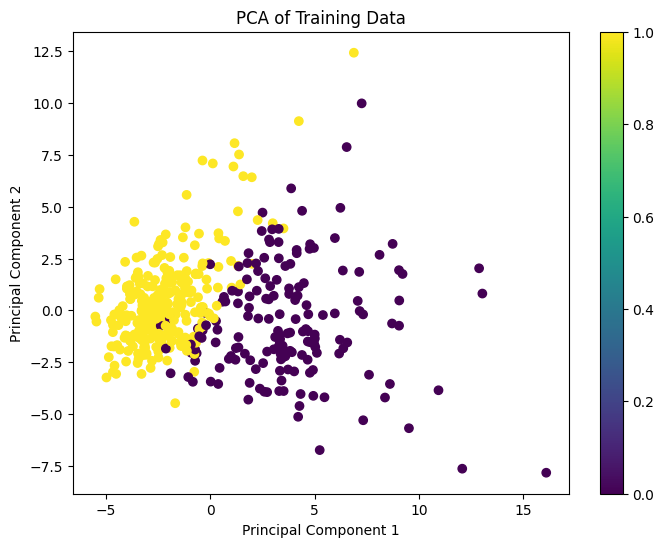

In [40]:
#Using PCA to visualize the decision boundary
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_train_2d = pca.fit_transform(x_train.T) #Transposing x_train back to its original shape (n_samples, n_features) before applying PCA. 
#This is necessary because PCA expects the input data to be in the shape of (n_samples, n_features), where n_samples is the number of 
# examples and n_features is the number of features for each example. Since we transposed x_train earlier to have the shape (n_features, n_samples),
# we need to transpose it back to (n_samples, n_features) before applying PCA. After this transformation, x_train_2d will have the shape 
# (n_samples, 2), where each example is represented in a 2D space defined by the first two principal components.

plt.figure(figsize=(8,6))
plt.scatter(x_train_2d[:,0], x_train_2d[:,1], c=y_train.flatten(), cmap='viridis')
plt.title('PCA of Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar()
plt.show()

#Plotting the decision boundary
def plot_decision_boundary(X, y, W1, b1, W2, b2):
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    
    grid = np.c_[xx.ravel(), yy.ravel()].T
    Z = predict(grid, W1, b1, W2, b2)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[0, :], X[1, :], c=y.flatten(), edgecolors='k', marker='o', s=100)
    plt.title('Decision Boundary')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

